In [ ]:
from transformers import AutoModel, AutoTokenizer
from conllu import parse_incr
import warnings
from sklearn.exceptions import InconsistentVersionWarning

# Ignore the version mismatch warning globally
warnings.filterwarnings("ignore", category=InconsistentVersionWarning)
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import spearmanr
from scipy.sparse.csgraph import minimum_spanning_tree
from Probe_analysis import StructuralProbeAnalyzer
from transformers import AutoModel, AutoTokenizer
import networkx as nx
from matplotlib.font_manager import fontManager, FontProperties
from visualizer import Visualizer
print(os.getcwd())

In [2]:
viz = Visualizer()

# Probe Analysis

## BERT-en

In [3]:
viz.load_tree_results(["COL-BERT-en", "GFW-BERT-en", "JUS-BERT-en", "KOP-BERT-en", "TYE-BERT-en", "ZEK-BERT-en"])
viz.load_probe_results(["COL-BERT-en", "GFW-BERT-en", "JUS-BERT-en", "KOP-BERT-en", "TYE-BERT-en", "ZEK-BERT-en"])
viz.load_weight_results(["COL-BERT-en", "GFW-BERT-en", "JUS-BERT-en", "KOP-BERT-en", "TYE-BERT-en", "ZEK-BERT-en"]);

Loaded tree results for COL-BERT-en - Layer 6
Loaded tree results for GFW-BERT-en - Layer 6
Loaded tree results for JUS-BERT-en - Layer 6
Loaded tree results for KOP-BERT-en - Layer 6
Loaded tree results for TYE-BERT-en - Layer 6
Loaded tree results for ZEK-BERT-en - Layer 6
Loaded probe results for COL-BERT-en - probe_results_english_subject_COL-BERT-en
Loaded probe results for GFW-BERT-en - probe_results_english_subject_GFW-BERT-en
Loaded probe results for JUS-BERT-en - probe_results_english_subject_JUS-BERT-en
Loaded probe results for KOP-BERT-en - probe_results_english_subject_KOP-BERT-en
Loaded probe results for TYE-BERT-en - probe_results_english_subject_TYE-BERT-en
Loaded probe results for ZEK-BERT-en - probe_results_english_subject_ZEK-BERT-en
Loaded weight results for COL-BERT-en
Loaded weight results for GFW-BERT-en
Loaded weight results for JUS-BERT-en
Loaded weight results for KOP-BERT-en
Loaded weight results for TYE-BERT-en
Loaded weight results for ZEK-BERT-en


In [4]:
viz.average_weight_results(["COL-BERT-en", "GFW-BERT-en", "JUS-BERT-en", "KOP-BERT-en", "TYE-BERT-en", "ZEK-BERT-en"], 
                          output_name="BERT-en-avg")

Saved averaged weight results: visualizer_results/averaged_weight/averaged_weight_BERT-en-avg.pkl


,Layer,Type,Comparison,Max_Diff,Mean_Diff
0,0,Attn_LayerNorm,BERT-language vs BERT-base,0.000433,0.000144
1,0,Attn_LayerNorm,BERT-semantic vs BERT-base,0.000254,0.000111
2,0,Attn_LayerNorm,BERT-whole vs BERT-base,0.001045,0.000312
3,0,Attn_Output,BERT-language vs BERT-base,0.000499,0.000150
4,0,Attn_Output,BERT-semantic vs BERT-base,0.000258,0.000110
...,...,...,...,...,...
181,Embedding,Emb_LayerNorm,BERT-semantic vs BERT-base,0.000253,0.000110
182,Embedding,Emb_LayerNorm,BERT-whole vs BERT-base,0.001000,0.000318
183,Embedding,Embedding,BERT-language vs BERT-base,0.000514,0.000011
184,Embedding,Embedding,BERT-semantic vs BERT-base,0.000259,0.000007


In [5]:
viz.average_probe_results(["COL-BERT-en", "GFW-BERT-en", "JUS-BERT-en", "KOP-BERT-en", "TYE-BERT-en", "ZEK-BERT-en"], 
                         output_name="BERT-en-avg")

,Layer,Model,Root Accuracy,Depth Spearman,Distance Spearman,UUAS,Root Accuracy_std,Depth Spearman_std,UUAS_std,Distance Spearman_std
0,1,BERT-base,0.553202,0.790693,0.142063,0.220785,0.000000,5.139079e-08,0.000861,0.000006
1,1,BERT-language,0.550875,0.790404,0.144362,0.214060,0.005330,4.567547e-04,0.008726,0.002556
2,1,BERT-semantic,0.552560,0.790695,0.141917,0.220745,0.001205,3.158307e-04,0.006514,0.004383
3,1,BERT-whole,0.554405,0.790744,0.137677,0.217687,0.003967,5.399116e-04,0.009869,0.012721
4,2,BERT-base,0.546943,0.799376,0.183258,0.270134,0.000000,1.068420e-08,0.000000,0.000341
5,2,BERT-language,0.545258,0.798940,0.178832,0.275741,0.001871,1.042709e-03,0.007530,0.007909
6,2,BERT-semantic,0.545498,0.799112,0.189901,0.270558,0.001776,5.162781e-04,0.002867,0.011727
7,2,BERT-whole,0.544696,0.799030,0.170227,0.262139,0.008337,9.113438e-04,0.011227,0.019426
8,3,BERT-base,0.582090,0.813429,0.231657,0.287060,0.000000,1.204550e-07,0.000000,0.000009
9,3,BERT-language,0.579201,0.812916,0.225496,0.274502,0.004786,7.691260e-04,0.015053,0.006842


In [6]:
viz.average_tree_results(["COL-BERT-en", "GFW-BERT-en", "JUS-BERT-en", "KOP-BERT-en", "TYE-BERT-en", "ZEK-BERT-en"], 
                        layer_to_plot=6, output_name="BERT-en-avg");

Saved aggregated tree results: visualizer_results/averaged_tree/averaged_tree_layer6_BERT-en-avg.pkl


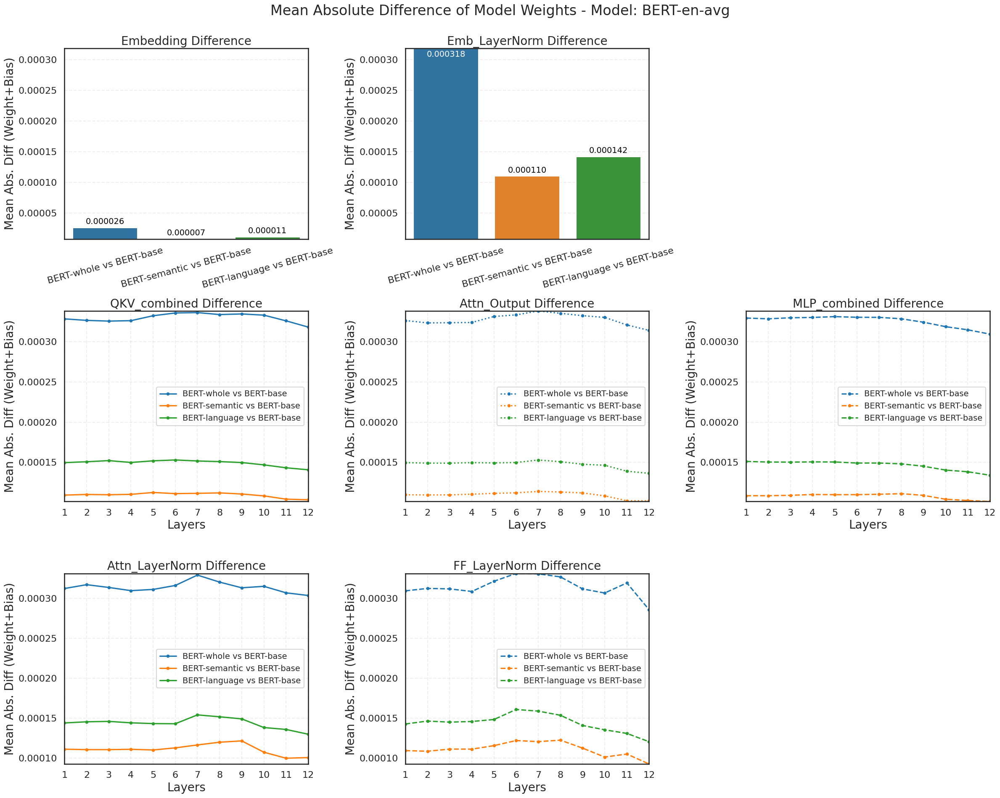

In [38]:
viz.plot_weight_analysis_from_file("BERT-en-avg") 

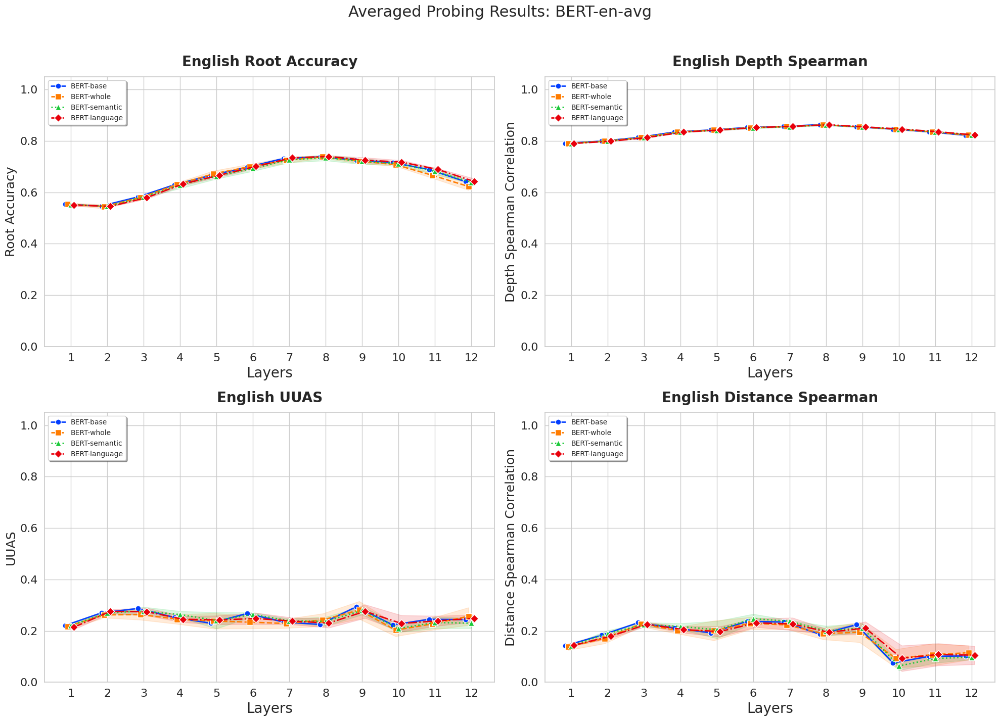

In [8]:
viz.plot_probe_results_from_file("BERT-en-avg")

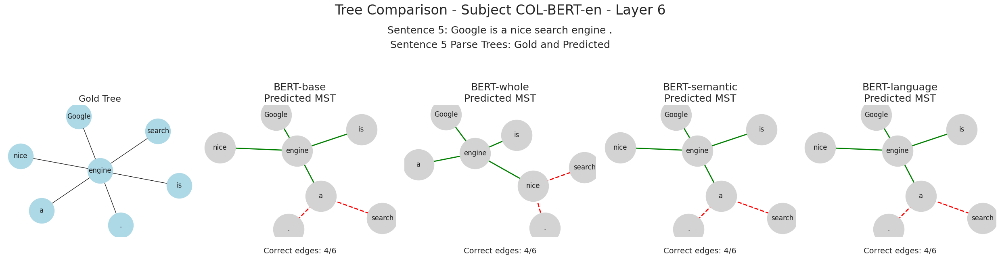

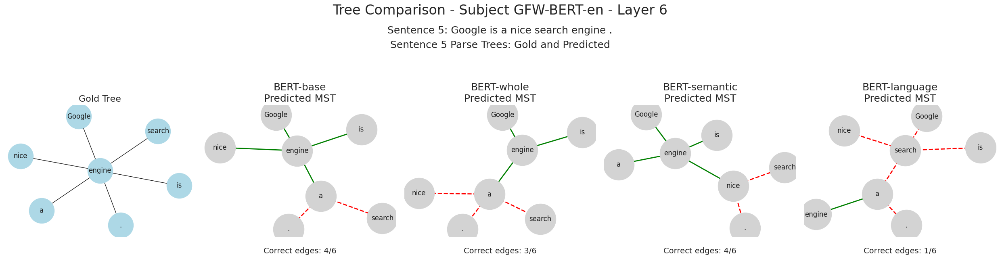

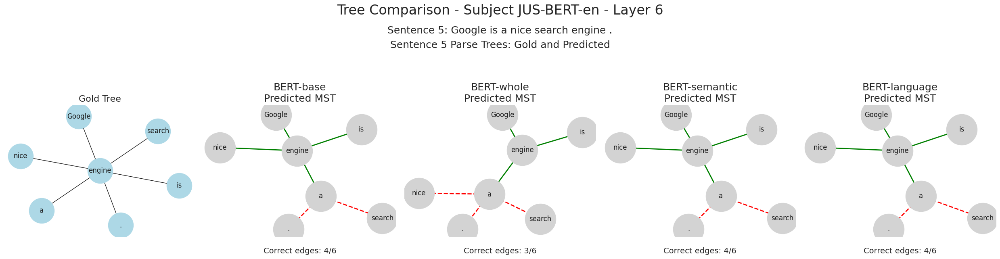

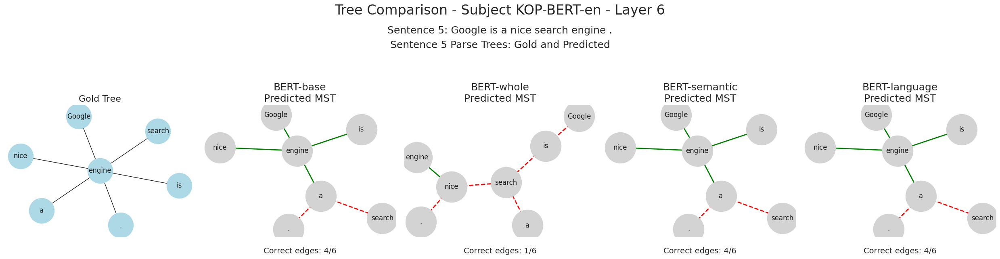

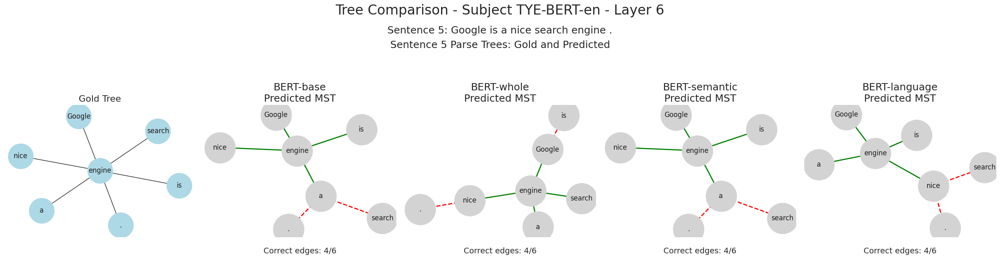

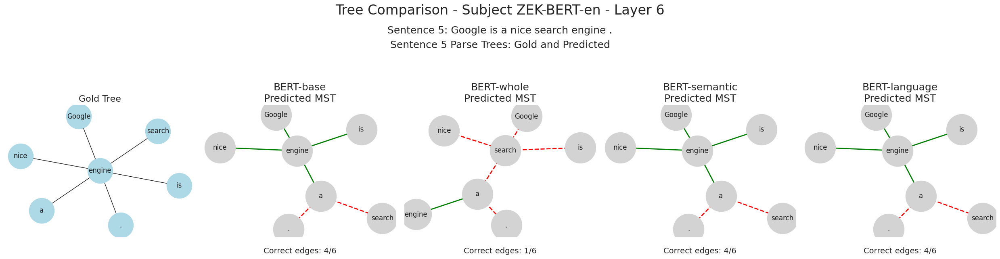

In [9]:
viz.plot_tree_comparison_subjects(["COL-BERT-en", "GFW-BERT-en", "JUS-BERT-en", "KOP-BERT-en", "TYE-BERT-en", "ZEK-BERT-en"], 6, sentence_idx=5)

## BERT-zh

In [10]:
# Load results
viz.load_tree_results(["COL-BERT-zh", "GFW-BERT-zh", "JUS-BERT-zh", "KOP-BERT-zh", "TYE-BERT-zh", "ZEK-BERT-zh"])
viz.load_probe_results(["COL-BERT-zh", "GFW-BERT-zh", "JUS-BERT-zh", "KOP-BERT-zh", "TYE-BERT-zh", "ZEK-BERT-zh"])
viz.load_weight_results(["COL-BERT-zh", "GFW-BERT-zh", "JUS-BERT-zh", "KOP-BERT-zh", "TYE-BERT-zh", "ZEK-BERT-zh"]);

Loaded tree results for COL-BERT-zh - Layer 6
Loaded tree results for GFW-BERT-zh - Layer 6
Loaded tree results for JUS-BERT-zh - Layer 6
Loaded tree results for KOP-BERT-zh - Layer 6
Loaded tree results for TYE-BERT-zh - Layer 6
Loaded tree results for ZEK-BERT-zh - Layer 6
Loaded probe results for COL-BERT-zh - probe_results_chinese_subject_COL-BERT-zh
Loaded probe results for GFW-BERT-zh - probe_results_chinese_subject_GFW-BERT-zh
Loaded probe results for JUS-BERT-zh - probe_results_chinese_subject_JUS-BERT-zh
Loaded probe results for KOP-BERT-zh - probe_results_chinese_subject_KOP-BERT-zh
Loaded probe results for TYE-BERT-zh - probe_results_chinese_subject_TYE-BERT-zh
Loaded probe results for ZEK-BERT-zh - probe_results_chinese_subject_ZEK-BERT-zh
Loaded weight results for COL-BERT-zh
Loaded weight results for GFW-BERT-zh
Loaded weight results for JUS-BERT-zh
Loaded weight results for KOP-BERT-zh
Loaded weight results for TYE-BERT-zh
Loaded weight results for ZEK-BERT-zh


In [11]:
viz.average_weight_results(["COL-BERT-zh", "GFW-BERT-zh", "JUS-BERT-zh", "KOP-BERT-zh", "TYE-BERT-zh", "ZEK-BERT-zh"], 
                          output_name="BERT-zh-avg")

viz.average_probe_results(["COL-BERT-zh", "GFW-BERT-zh", "JUS-BERT-zh", "KOP-BERT-zh", "TYE-BERT-zh", "ZEK-BERT-zh"], 
                         output_name="BERT-zh-avg")

viz.average_tree_results(["COL-BERT-zh", "GFW-BERT-zh", "JUS-BERT-zh", "KOP-BERT-zh", "TYE-BERT-zh", "ZEK-BERT-zh"], 
                        layer_to_plot=6, output_name="BERT-zh-avg");

Saved averaged weight results: visualizer_results/averaged_weight/averaged_weight_BERT-zh-avg.pkl
Saved aggregated tree results: visualizer_results/averaged_tree/averaged_tree_layer6_BERT-zh-avg.pkl


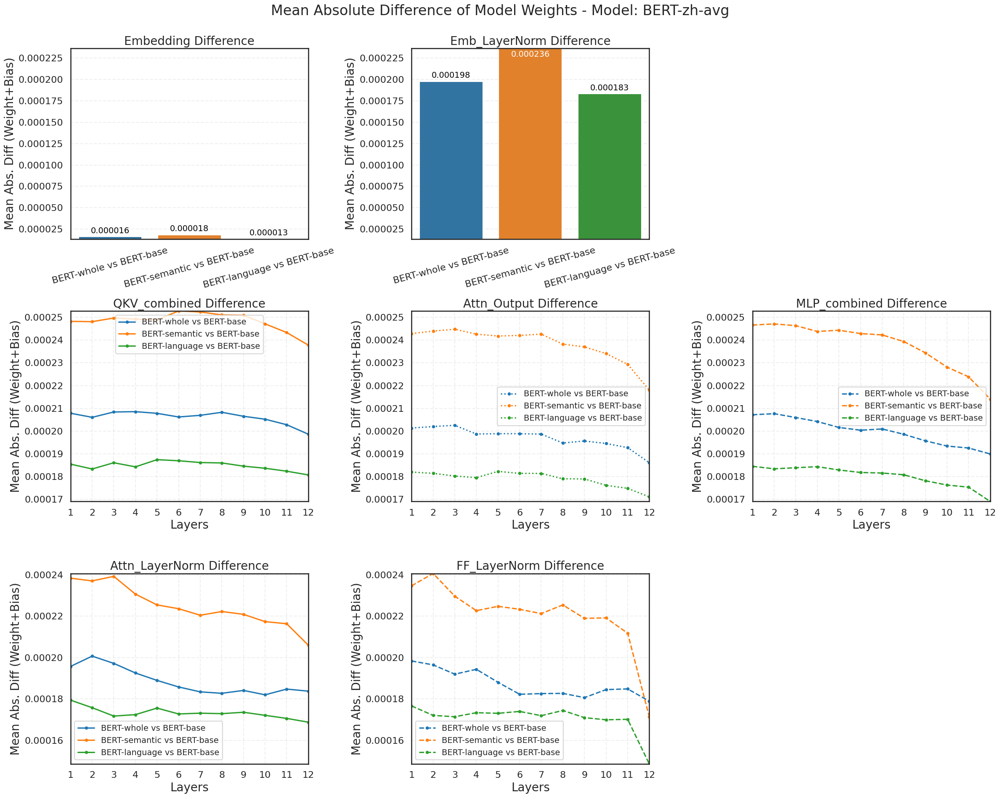

In [35]:
viz.plot_weight_analysis_from_file("BERT-zh-avg")

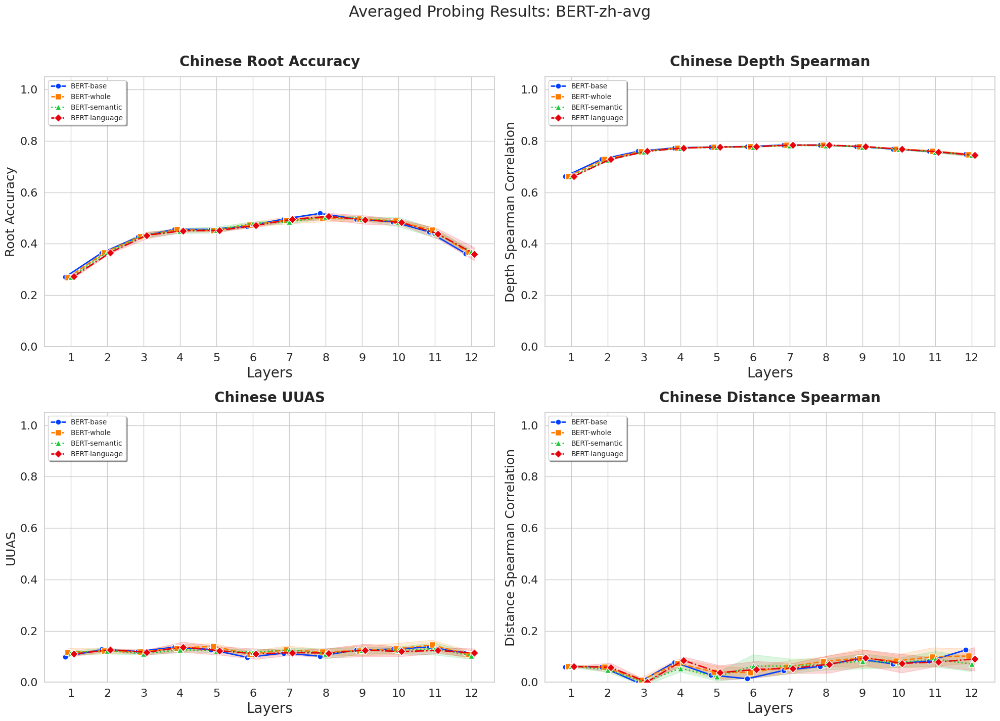

In [13]:
viz.plot_probe_results_from_file("BERT-zh-avg")

In [15]:
############# EXTRA##################


font_path = 'font/NotoSansMonoCJKsc-Regular.otf'

fontManager.addfont(font_path)

font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()

plt.rcParams['font.sans-serif'] = [font_name, 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

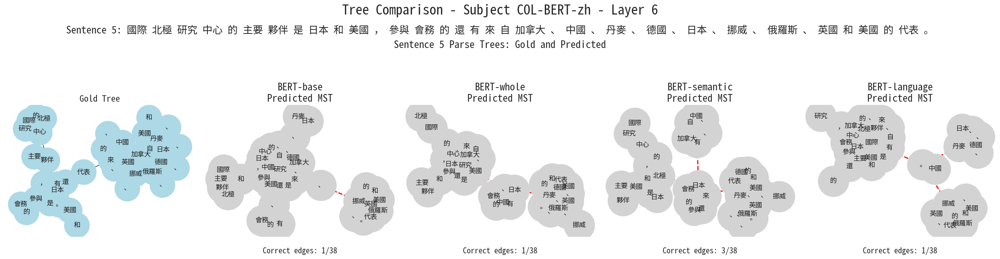

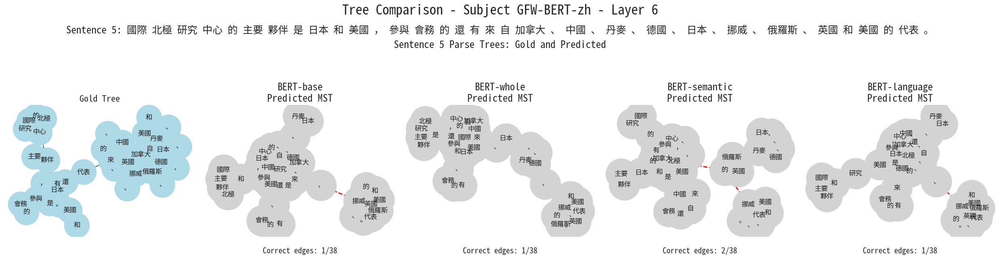

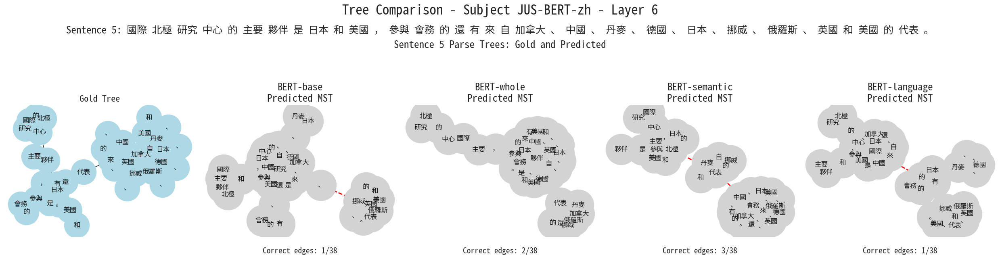

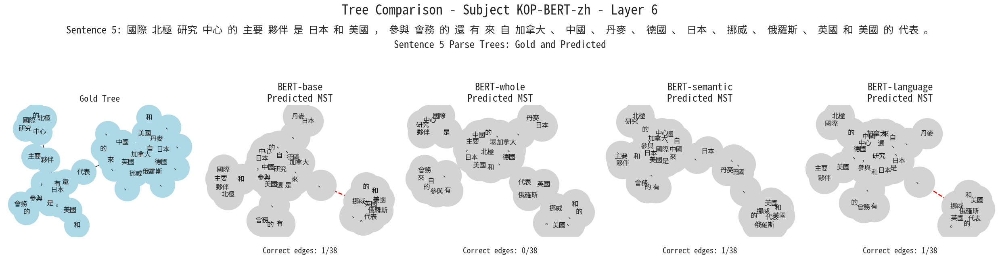

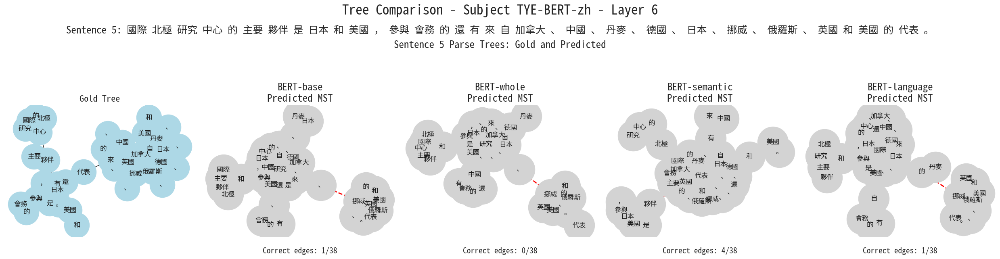

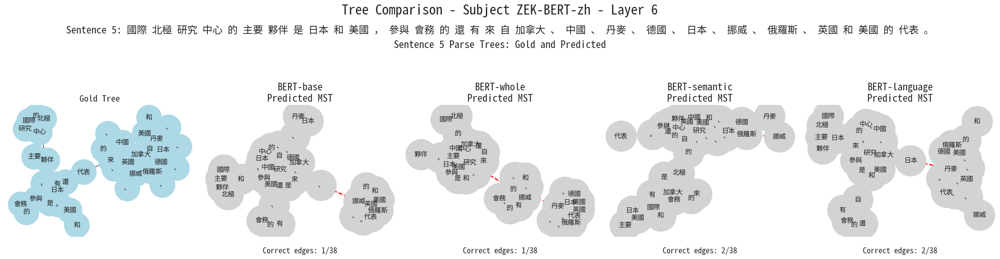

In [16]:
viz.plot_tree_comparison_subjects(["COL-BERT-zh", "GFW-BERT-zh", "JUS-BERT-zh", "KOP-BERT-zh", "TYE-BERT-zh", "ZEK-BERT-zh"], 6, sentence_idx=5)

## mBERT-en

In [17]:
# Load results
viz.load_tree_results(["COL-mBERT-en", "GFW-mBERT-en", "JUS-mBERT-en", "KOP-mBERT-en", "TYE-mBERT-en", "ZEK-mBERT-en"])
viz.load_probe_results(["COL-mBERT-en", "GFW-mBERT-en", "JUS-mBERT-en", "KOP-mBERT-en", "TYE-mBERT-en", "ZEK-mBERT-en"])
viz.load_weight_results(["COL-mBERT-en", "GFW-mBERT-en", "JUS-mBERT-en", "KOP-mBERT-en", "TYE-mBERT-en", "ZEK-mBERT-en"]);

Loaded tree results for COL-mBERT-en - Layer 6
Loaded tree results for GFW-mBERT-en - Layer 6
Loaded tree results for JUS-mBERT-en - Layer 6
Loaded tree results for KOP-mBERT-en - Layer 6
Loaded tree results for TYE-mBERT-en - Layer 6
Loaded tree results for ZEK-mBERT-en - Layer 6
Loaded probe results for COL-mBERT-en - probe_results_english_subject_COL-mBERT-en
Loaded probe results for GFW-mBERT-en - probe_results_english_subject_GFW-mBERT-en
Loaded probe results for JUS-mBERT-en - probe_results_english_subject_JUS-mBERT-en
Loaded probe results for KOP-mBERT-en - probe_results_english_subject_KOP-mBERT-en
Loaded probe results for TYE-mBERT-en - probe_results_english_subject_TYE-mBERT-en
Loaded probe results for ZEK-mBERT-en - probe_results_english_subject_ZEK-mBERT-en
Loaded weight results for COL-mBERT-en
Loaded weight results for GFW-mBERT-en
Loaded weight results for JUS-mBERT-en
Loaded weight results for KOP-mBERT-en
Loaded weight results for TYE-mBERT-en
Loaded weight results for

In [18]:
viz.average_weight_results(["COL-mBERT-en", "GFW-mBERT-en", "JUS-mBERT-en", "KOP-mBERT-en", "TYE-mBERT-en", "ZEK-mBERT-en"], 
                          output_name="mBERT-en-avg")

viz.average_probe_results(["COL-mBERT-en", "GFW-mBERT-en", "JUS-mBERT-en", "KOP-mBERT-en", "TYE-mBERT-en", "ZEK-mBERT-en"], 
                         output_name="mBERT-en-avg")

viz.average_tree_results(["COL-mBERT-en", "GFW-mBERT-en", "JUS-mBERT-en", "KOP-mBERT-en", "TYE-mBERT-en", "ZEK-mBERT-en"], 
                        layer_to_plot=6, output_name="mBERT-en-avg");

Saved averaged weight results: visualizer_results/averaged_weight/averaged_weight_mBERT-en-avg.pkl
Saved aggregated tree results: visualizer_results/averaged_tree/averaged_tree_layer6_mBERT-en-avg.pkl


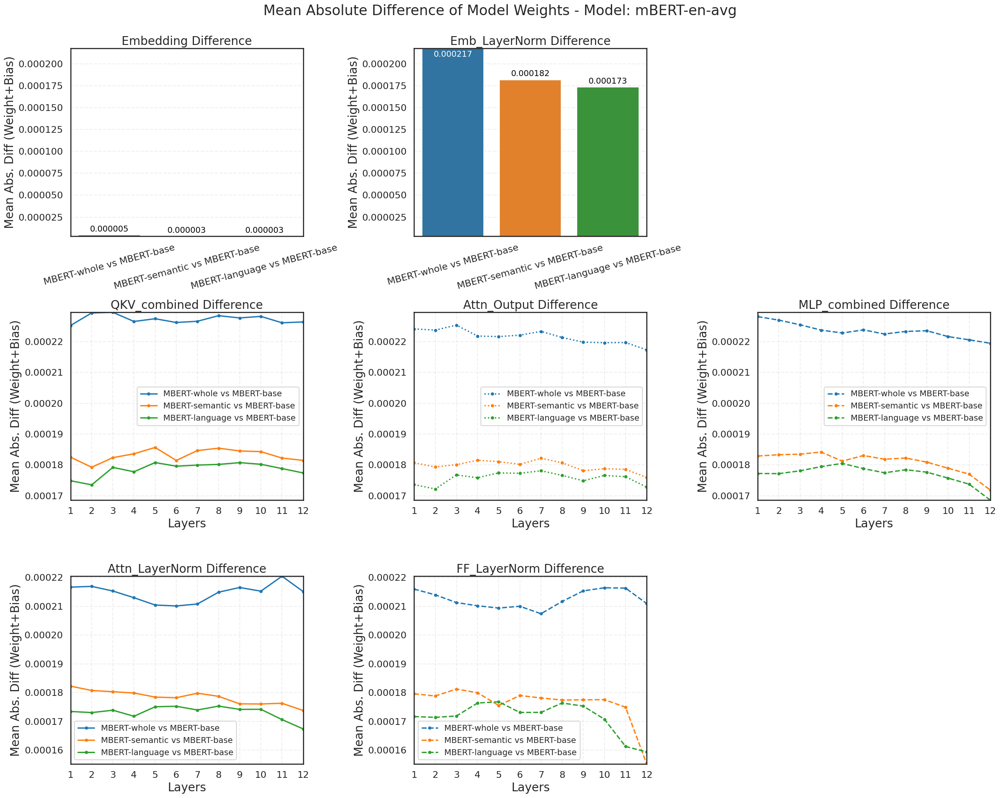

In [36]:
viz.plot_weight_analysis_from_file("mBERT-en-avg")

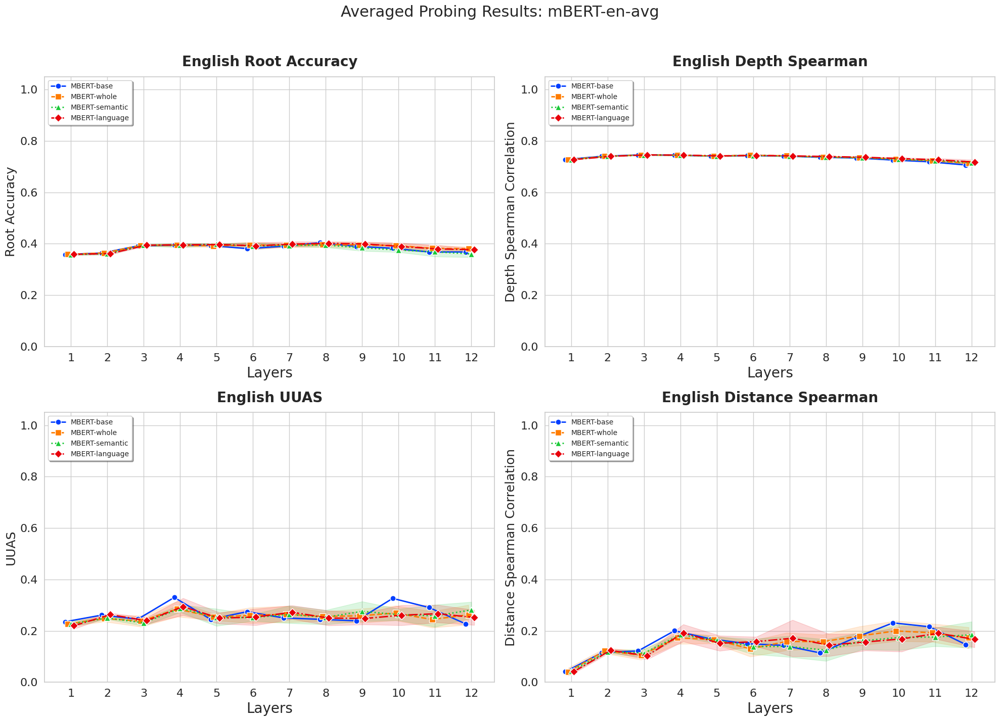

In [20]:
viz.plot_probe_results_from_file("mBERT-en-avg")

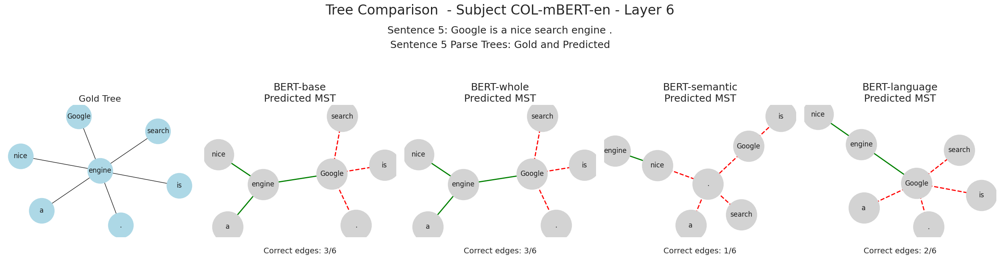

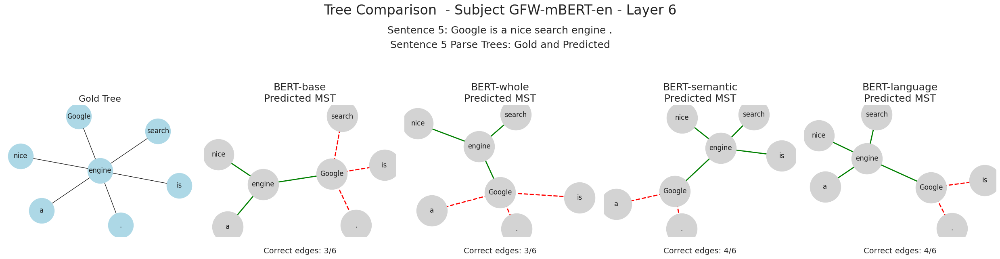

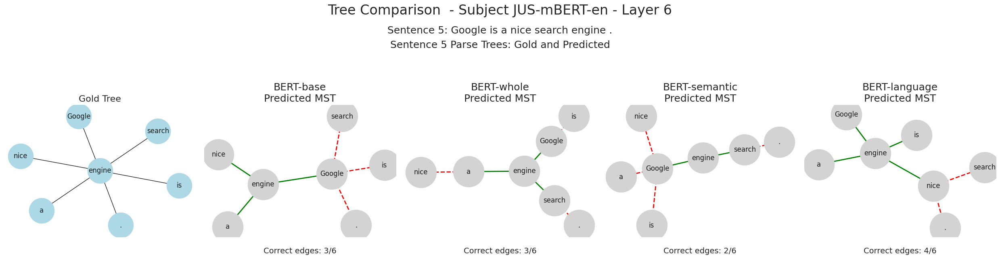

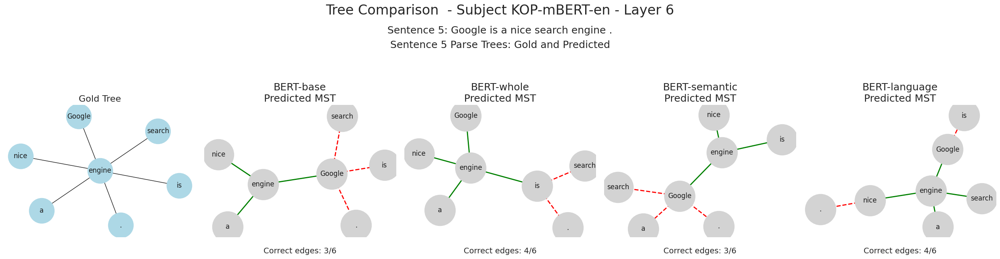

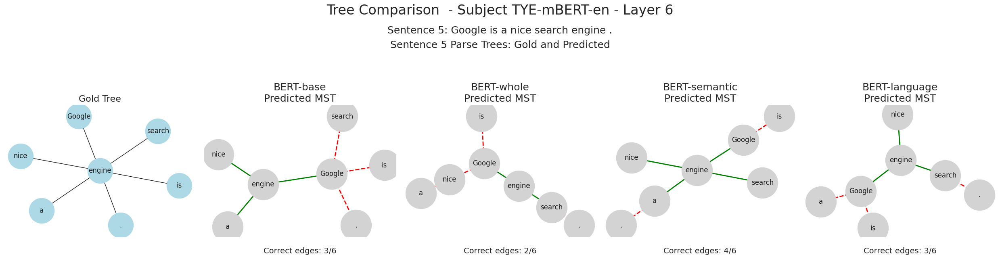

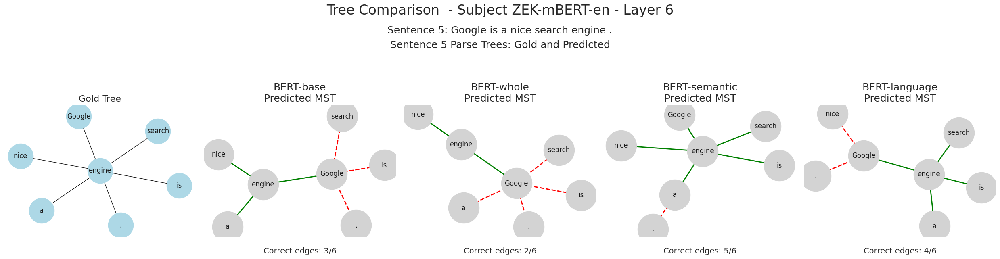

In [21]:
viz.plot_tree_comparison_subjects(["COL-mBERT-en", "GFW-mBERT-en", "JUS-mBERT-en", "KOP-mBERT-en", "TYE-mBERT-en", "ZEK-mBERT-en"], 6, sentence_idx=5)

## mBERT-zh

In [22]:
viz.load_tree_results(["COL-mBERT-zh", "GFW-mBERT-zh", "JUS-mBERT-zh", "KOP-mBERT-zh", "TYE-mBERT-zh", "ZEK-mBERT-zh"])
viz.load_probe_results(["COL-mBERT-zh", "GFW-mBERT-zh", "JUS-mBERT-zh", "KOP-mBERT-zh", "TYE-mBERT-zh", "ZEK-mBERT-zh"])
viz.load_weight_results(["COL-mBERT-zh", "GFW-mBERT-zh", "JUS-mBERT-zh", "KOP-mBERT-zh", "TYE-mBERT-zh", "ZEK-mBERT-zh"]);

Loaded tree results for COL-mBERT-zh - Layer 6
Loaded tree results for GFW-mBERT-zh - Layer 6
Loaded tree results for JUS-mBERT-zh - Layer 6
Loaded tree results for KOP-mBERT-zh - Layer 6
Loaded tree results for TYE-mBERT-zh - Layer 6
Loaded tree results for ZEK-mBERT-zh - Layer 6
Loaded probe results for COL-mBERT-zh - probe_results_chinese_subject_COL-mBERT-zh
Loaded probe results for GFW-mBERT-zh - probe_results_chinese_subject_GFW-mBERT-zh
Loaded probe results for JUS-mBERT-zh - probe_results_chinese_subject_JUS-mBERT-zh
Loaded probe results for KOP-mBERT-zh - probe_results_chinese_subject_KOP-mBERT-zh
Loaded probe results for TYE-mBERT-zh - probe_results_chinese_subject_TYE-mBERT-zh
Loaded probe results for ZEK-mBERT-zh - probe_results_chinese_subject_ZEK-mBERT-zh
Loaded weight results for COL-mBERT-zh
Loaded weight results for GFW-mBERT-zh
Loaded weight results for JUS-mBERT-zh
Loaded weight results for KOP-mBERT-zh
Loaded weight results for TYE-mBERT-zh
Loaded weight results for

In [23]:
viz.average_weight_results(["COL-mBERT-zh", "GFW-mBERT-zh", "JUS-mBERT-zh", "KOP-mBERT-zh", "TYE-mBERT-zh", "ZEK-mBERT-zh"], 
                          output_name="mBERT-zh-avg")

viz.average_probe_results(["COL-mBERT-zh", "GFW-mBERT-zh", "JUS-mBERT-zh", "KOP-mBERT-zh", "TYE-mBERT-zh", "ZEK-mBERT-zh"], 
                         output_name="mBERT-zh-avg")

viz.average_tree_results(["COL-mBERT-zh", "GFW-mBERT-zh", "JUS-mBERT-zh", "KOP-mBERT-zh", "TYE-mBERT-zh", "ZEK-mBERT-zh"], 
                        layer_to_plot=6, output_name="mBERT-zh-avg");

Saved averaged weight results: visualizer_results/averaged_weight/averaged_weight_mBERT-zh-avg.pkl
Saved aggregated tree results: visualizer_results/averaged_tree/averaged_tree_layer6_mBERT-zh-avg.pkl


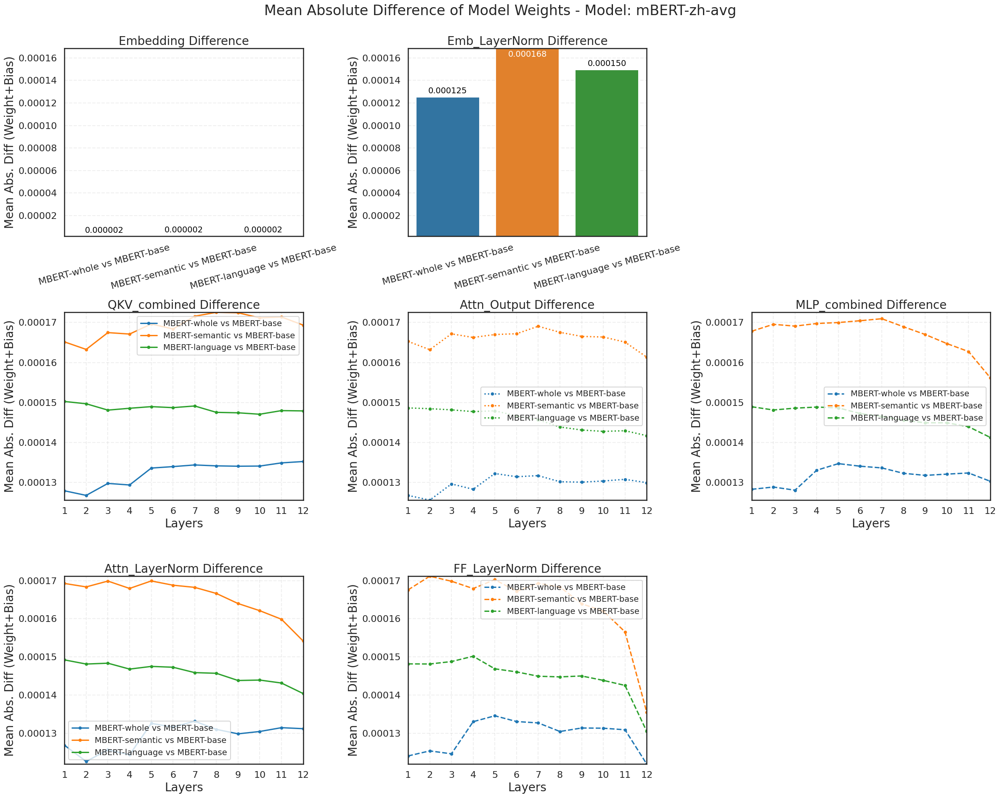

In [37]:
viz.plot_weight_analysis_from_file("mBERT-zh-avg")

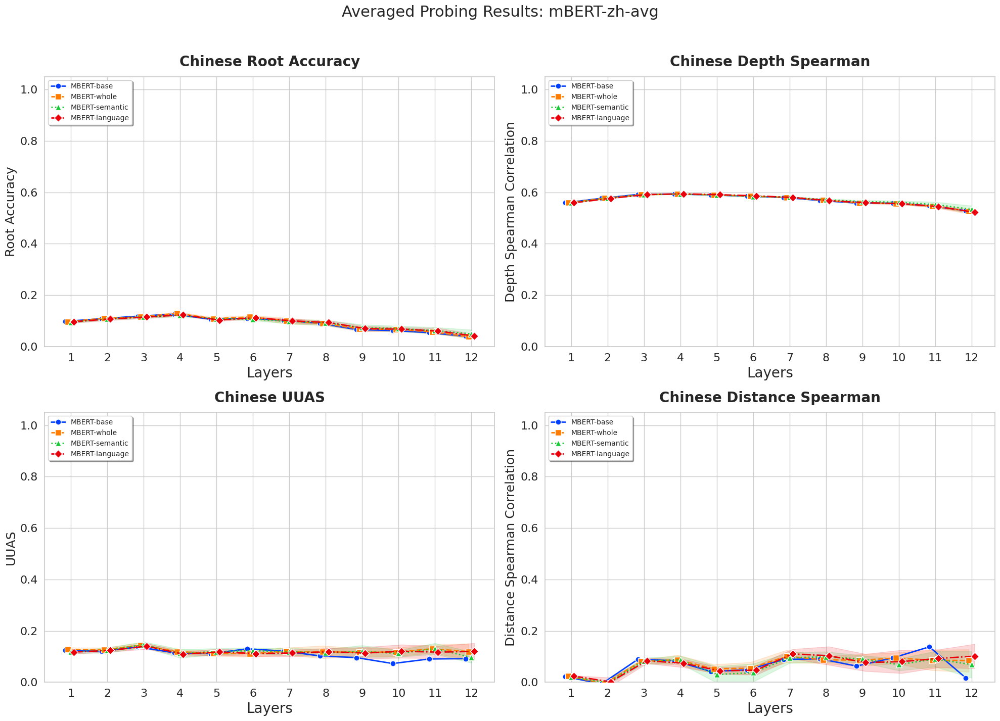

In [25]:
viz.plot_probe_results_from_file("mBERT-zh-avg")

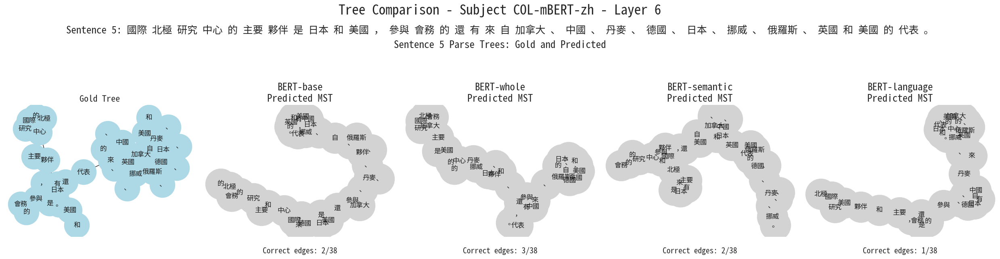

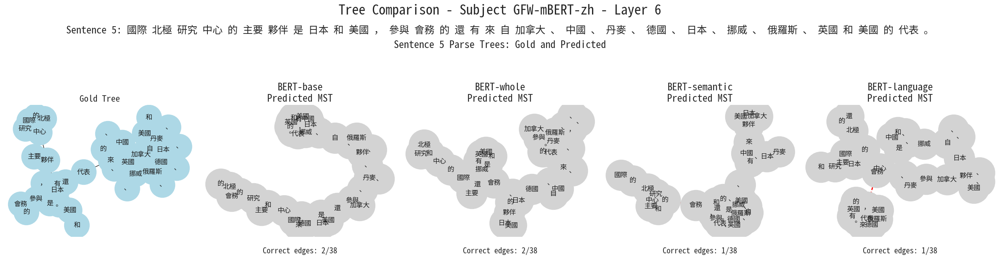

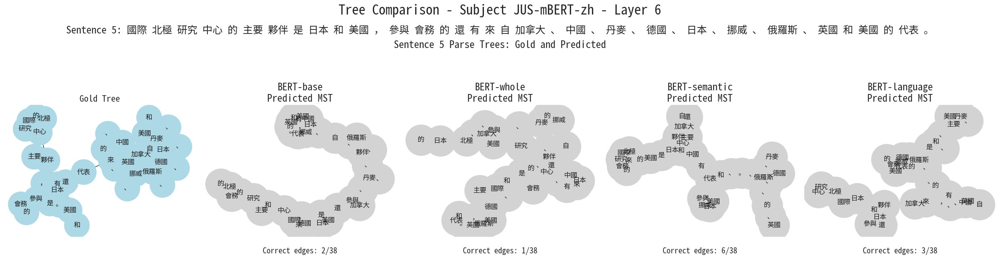

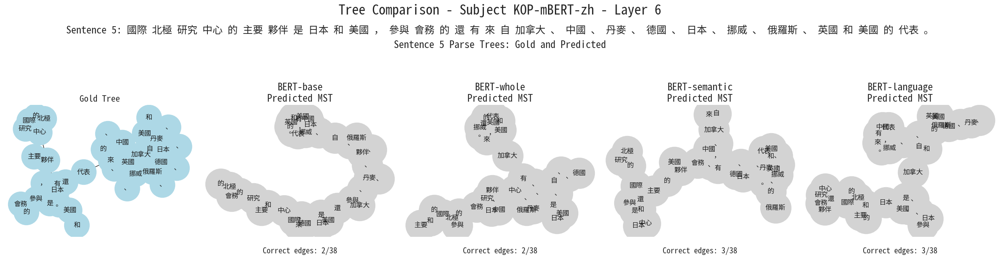

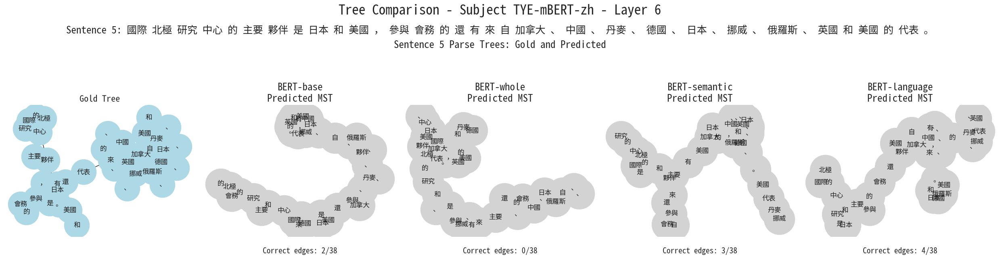

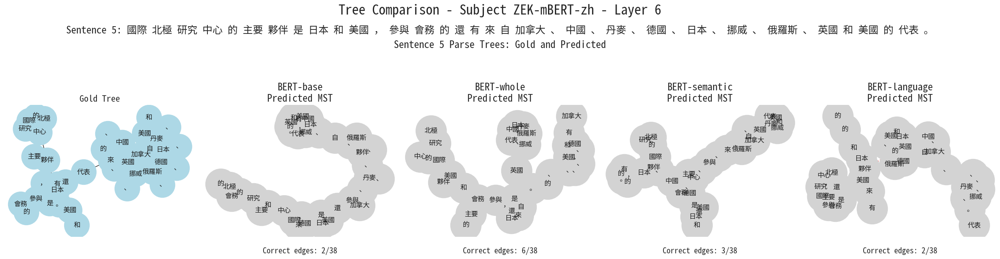

In [26]:
############# EXTRA##################


font_path = 'font/NotoSansMonoCJKsc-Regular.otf'

fontManager.addfont(font_path)

font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()

plt.rcParams['font.sans-serif'] = [font_name, 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

viz.plot_tree_comparison_subjects(["COL-mBERT-zh", "GFW-mBERT-zh", "JUS-mBERT-zh", "KOP-mBERT-zh", "TYE-mBERT-zh", "ZEK-mBERT-zh"], 6, sentence_idx=5)

# Representation Similarity Analysis

## BERT-en and mBERT-en Models

In [27]:
viz.load_rsa_results(["COL-en", "GFW-en", "JUS-en", "KOP-en", "TYE-en", "ZEK-en"]);

Loaded RSA results for COL-en - rsa_xnli_multi_family_english_subject_COL-en
Loaded RSA results for GFW-en - rsa_xnli_multi_family_english_subject_GFW-en
Loaded RSA results for JUS-en - rsa_xnli_multi_family_english_subject_JUS-en
Loaded RSA results for KOP-en - rsa_xnli_multi_family_english_subject_KOP-en
Loaded RSA results for TYE-en - rsa_xnli_multi_family_english_subject_TYE-en
Loaded RSA results for ZEK-en - rsa_xnli_multi_family_english_subject_ZEK-en


In [28]:
viz.average_rsa_results(subject_codes=["COL-en", "GFW-en", "JUS-en", "KOP-en", "TYE-en", "ZEK-en"], output_name="en-avg");

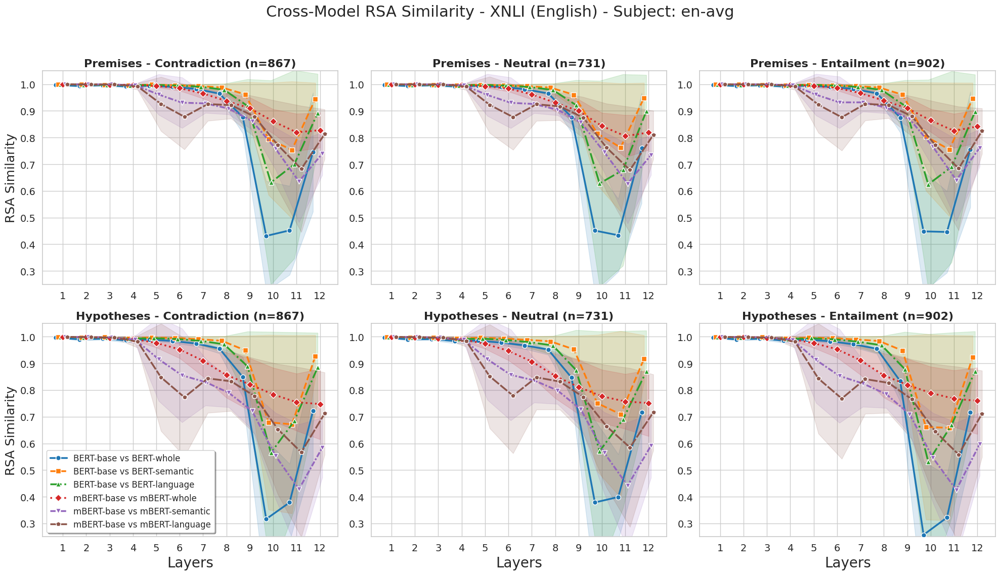

In [29]:
viz.plot_rsa_results_from_file("en-avg", y_limlow=0.25)

In [30]:
viz.load_rsa_results(["COL-zh", "GFW-zh", "JUS-zh", "KOP-zh", "TYE-zh", "ZEK-zh"]);

Loaded RSA results for COL-zh - rsa_xnli_multi_family_chinese_subject_COL-zh
Loaded RSA results for GFW-zh - rsa_xnli_multi_family_chinese_subject_GFW-zh
Loaded RSA results for JUS-zh - rsa_xnli_multi_family_chinese_subject_JUS-zh
Loaded RSA results for KOP-zh - rsa_xnli_multi_family_chinese_subject_KOP-zh
Loaded RSA results for TYE-zh - rsa_xnli_multi_family_chinese_subject_TYE-zh
Loaded RSA results for ZEK-zh - rsa_xnli_multi_family_chinese_subject_ZEK-zh


In [31]:
viz.average_rsa_results(subject_codes=["COL-zh", "GFW-zh", "JUS-zh", "KOP-zh", "TYE-zh", "ZEK-zh"], output_name="zh-avg");

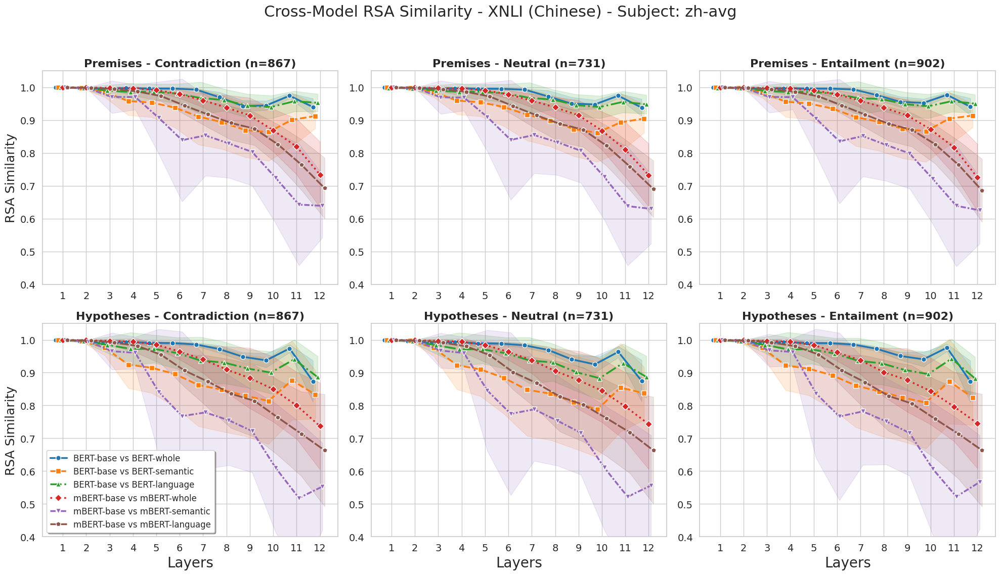

In [32]:
viz.plot_rsa_results_from_file("zh-avg")